In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [34]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,random_state=10,n_features=2,n_redundant=0,n_classes=2,n_clusters_per_class=2)

In [24]:
type(X)

numpy.ndarray

<Axes: xlabel='0', ylabel='1'>

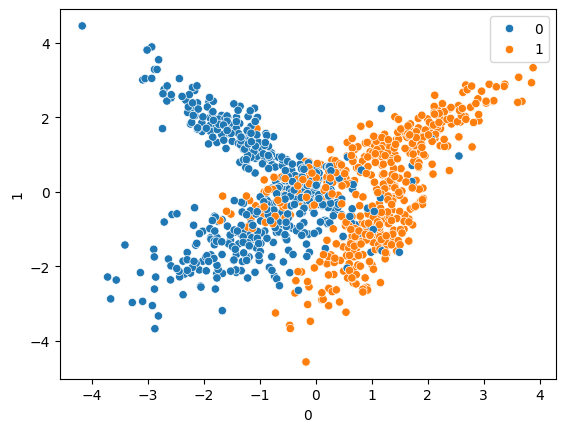

In [70]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=10)

In [72]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,y_train)
y_pred0=svc.predict(X_test)

In [73]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred0))
print(confusion_matrix(y_test,y_pred0))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       106
           1       0.87      0.79      0.83        94

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200

[[95 11]
 [20 74]]


## precomputaion

In [76]:
svc=SVC(kernel="linear")
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print(classification_report(y_test,y_pred0))
print(confusion_matrix(y_test,y_pred0))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       106
           1       0.87      0.79      0.83        94

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200

[[95 11]
 [20 74]]


In [77]:
svc=SVC(kernel="poly")
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print(classification_report(y_test,y_pred0))
print(confusion_matrix(y_test,y_pred0))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       106
           1       0.87      0.79      0.83        94

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200

[[95 11]
 [20 74]]


In [79]:
svc=SVC(kernel="sigmoid")
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print(classification_report(y_test,y_pred0))
print(confusion_matrix(y_test,y_pred0))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       106
           1       0.87      0.79      0.83        94

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200

[[95 11]
 [20 74]]


## hyperparameter tuning

In [109]:
from sklearn.model_selection import GridSearchCV
model=SVC()
para={"kernel":['rbf'],
        "gamma":[1,0.1,0.01,0.001,0.0001],
        "C":[0.1,1,10,100,1000],
        "class_weight":["balanced"]
     }
grid=GridSearchCV(estimator=model,param_grid=para,verbose=3,cv=5,n_jobs=-1,refit=True)

In [110]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 4/5] END ...C=0.1, gamma=0.0001, kernel=rbf;, score=0.506 total time=   0.0s
[CV 5/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 3/5] END ......C=1, gamma=0.001, kernel=rbf;, score=0.894 total time=   0.0s
[CV 1/5] END .........C=10, gamma=1, kernel=rbf;, score=0.875 total time=   0.0s
[CV 2/5] END .........C=10, gamma=1, kernel=rbf;, score=0.875 total time=   0.0s
[CV 5/5] END ......C=10, gamma=0.01, kernel=rbf;, score=0.900 total time=   0.0s
[CV 1/5] END .....C=10, gamma=0.001, kernel=rbf;, score=0.863 total time=   0.0s
[CV 4/5] END ........C=100, gamma=1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 5/5] END ........C=100, gamma=1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 4/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 5/5] END .....C=1000, gamma=0.1, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'class_weight': ['balanced'],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [111]:
y_pred1=grid.predict(X_test)
grid.best_params_

{'C': 10, 'class_weight': 'balanced', 'gamma': 1, 'kernel': 'rbf'}

In [112]:
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       106
           1       0.86      0.81      0.84        94

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200

[[94 12]
 [18 76]]
[CV 5/5] END C=1, class_weight=balanced, gamma=1, kernel=rbf;, score=0.919 total time=   0.0s
[CV 5/5] END C=1, class_weight=balanced, gamma=0.1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 1/5] END C=1, class_weight=balanced, gamma=0.01, kernel=rbf;, score=0.863 total time=   0.0s
[CV 3/5] END C=10, class_weight=balanced, gamma=1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 4/5] END C=10, class_weight=balanced, gamma=1, kernel=rbf;, score=0.906 total time=   0.0s
[CV 5/5] END C=10, class_weight=balanced, gamma=1, kernel=rbf;, score=0.931 total time=   0.0s
[CV 1/5] END C=10, class_weight=balanced, gamma=0.1, kernel=rbf;, score=0.881 tota

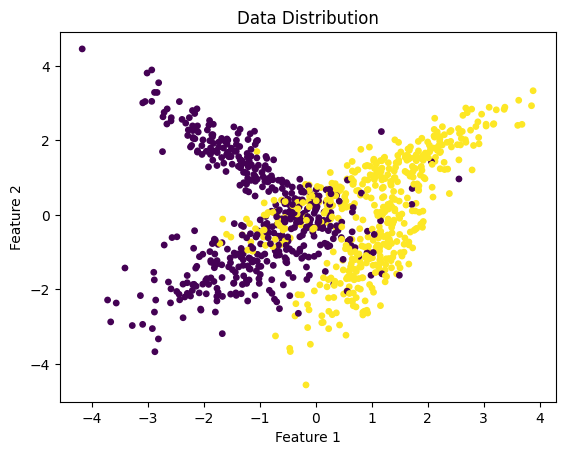

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86       106
           1       0.86      0.81      0.84        94

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200


Confusion Matrix:
 [[94 12]
 [18 76]]


In [92]:
# Import necessary libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Generate synthetic classification data
X, y = make_classification(
    n_samples=1000,       # Total samples
    n_features=2,         # Number of features
    n_redundant=0,        # No redundant features
    n_classes=2,          # Binary classification
    n_clusters_per_class=2,
    random_state=10       # Seed for reproducibility
)

# Step 2: Visualize the data distribution
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=15)
plt.title("Data Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

# Step 4: Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Define the SVM model and parameter grid
model = SVC()
param_grid = {
    "kernel": ['rbf'],                      # Using RBF kernel
    "gamma": [1, 0.1, 0.01, 0.001, 0.0001], # Range of gamma values
    "C": [0.1, 1, 10, 100, 1000]            # Range of C values
}

# Step 6: Set up GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    verbose=3,    # Show progress during grid search
    cv=5,         # 5-fold cross-validation
    n_jobs=-1,    # Use all CPU cores for parallelism
    refit=True    # Automatically refit the best model on the entire training set
)

# Step 7: Fit the grid search to the training data
grid.fit(X_train, y_train)

# Step 8: Predict using the best model
y_pred1 = grid.predict(X_test)

# Step 9: Evaluate the model
print("Best Parameters:", grid.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred1))
